# TI IWR6843 mmWave Radar Fall Detection Dataset — Easy Explorer & Reader Guide

This notebook provides a complete guide and **Interactive 4D Scrubber** for the **TI IWR6843 mmWave Radar Fall Detection Dataset** (`datasets/mmwave-radar-fall-detection/GatheredData`).

---

### Dataset Overview & Structure

The dataset contains **102 motion recordings** collected from a **TI IWR6843 mmWave Radar sensor** (60-64 GHz) across **3 human subjects** (Areeb, Raffay, Towsif):

- **51 Fall Recordings** ( `Fall` folder):
  - **Front Fall** (21 recordings)
  - **Back Fall** (15 recordings)
  - **Side Fall** (15 recordings)
- **51 Not-Fall / ADL Recordings** ( `Not` folder):
  - **Bowing / Bending** (15 recordings)
  - **Squatting / Crouching** (15 recordings)
  - **Walking** (21 recordings)

---

### CSV Data Schema (Column Breakdown)

Each CSV file represents a single ~2.5-second motion trial (~25 frames @ 10 FPS):

| Column | Description | Unit / Range |
| :--- | :--- | :--- |
| `frame` | Frame index within recording | `0 ... 25` (~10 FPS) |
| `DetObj#` | Detection point index within frame | `0 ... M` points |
| `x` | 3D Lateral coordinate in room space | meters ($X \in [-2.0, 2.0]$) |
| `y` | 3D Depth coordinate in room space | meters ($Y \in [0.0, 6.0]$) |
| `z` | 3D Elevation / Height coordinate | meters ($Z \in [-0.5, 2.2]$) |
| `v` | Radial Doppler velocity | m/s ($v \in [-3.0, 3.0]$) |
| `snr` | Signal-to-Noise Ratio | raw energy value |
| `noise` | Noise floor level | raw noise value |


## 1. Master Dataset Catalog Table

Below is an automatically indexed catalog table listing all **102 CSV recordings** with Subject name, Action type, Class label (Fall vs ADL), Total points, Frame count, Duration, and File path.


In [1]:
import glob
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

data_dir = Path("datasets/mmwave-radar-fall-detection/GatheredData")
if not data_dir.exists():
    data_dir = Path("../datasets/mmwave-radar-fall-detection/GatheredData")
if not data_dir.exists():
    data_dir = Path("datasets/mmwave-fall-detection-dataset/GatheredData")
if not data_dir.exists():
    data_dir = Path("../datasets/mmwave-fall-detection-dataset/GatheredData")

fall_files = sorted(list((data_dir / "Fall").glob("*.csv")))
not_files = sorted(list((data_dir / "Not").glob("*.csv")))

records = []

for folder, file_list, class_lbl in [("Fall", fall_files, "[FALL]"), ("Not", not_files, "[ADL] Non-Fall")]:
    for p in file_list:
        fname = p.stem # e.g. Areeb_back_1
        parts = fname.split("_")
        subject = parts[0] if len(parts) >= 1 else "Unknown"
        motion_code = parts[1] if len(parts) >= 2 else "unknown"
        trial_num = parts[2] if len(parts) >= 3 else "1"
        
       # Friendly action name
        action_map = {
            "back": "Back Fall",
            "front": "Front Fall",
            "side": "Side Fall",
            "bow": "Bowing / Bending",
            "squat": "Squatting",
            "walk": "Walking"
        }
        action_name = action_map.get(motion_code, motion_code.capitalize())
        
        df_temp = pd.read_csv(p)
        num_frames = df_temp["frame"].nunique() if "frame" in df_temp.columns else 0
        total_points = len(df_temp)
        duration_s = round(num_frames / 10.0, 1)
        
        records.append({
            "Folder": folder,
            "Subject": subject,
            "Action Name": f"{action_name} #{trial_num}",
            "Class Label": class_lbl,
            "File Name": fname,
            "Total Points": total_points,
            "Total Frames": num_frames,
            "Duration (s)": f"{duration_s}s",
            "File Path": str(p)
        })

df_radar_catalog = pd.DataFrame(records)
print(f"Total CSV recordings cataloged: {len(df_radar_catalog)}")
print("\nClass Distribution:")
print(df_radar_catalog["Class Label"].value_counts())
df_radar_catalog.head(15)


Total CSV recordings cataloged: 102

Class Distribution:
Class Label
[FALL]            51
[ADL] Non-Fall    51
Name: count, dtype: int64


,Folder,Subject,Action Name,Class Label,File Name,Total Points,Total Frames,Duration (s),File Path
0,Fall,Areeb,Back Fall #1,[FALL],Areeb_back_1,238,24,2.4s,..\datasets\mmwave-radar-fall-detection\Gather...
1,Fall,Areeb,Back Fall #2,[FALL],Areeb_back_2,239,24,2.4s,..\datasets\mmwave-radar-fall-detection\Gather...
2,Fall,Areeb,Back Fall #3,[FALL],Areeb_back_3,261,24,2.4s,..\datasets\mmwave-radar-fall-detection\Gather...
3,Fall,Areeb,Back Fall #4,[FALL],Areeb_back_4,244,25,2.5s,..\datasets\mmwave-radar-fall-detection\Gather...
4,Fall,Areeb,Back Fall #5,[FALL],Areeb_back_5,259,25,2.5s,..\datasets\mmwave-radar-fall-detection\Gather...
5,Fall,Areeb,Front Fall #1,[FALL],Areeb_front_1,207,24,2.4s,..\datasets\mmwave-radar-fall-detection\Gather...
6,Fall,Areeb,Front Fall #2,[FALL],Areeb_front_2,254,24,2.4s,..\datasets\mmwave-radar-fall-detection\Gather...
7,Fall,Areeb,Front Fall #3,[FALL],Areeb_front_3,223,25,2.5s,..\datasets\mmwave-radar-fall-detection\Gather...
8,Fall,Areeb,Front Fall #4,[FALL],Areeb_front_4,228,24,2.4s,..\datasets\mmwave-radar-fall-detection\Gather...
9,Fall,Areeb,Front Fall #5,[FALL],Areeb_front_5,219,24,2.4s,..\datasets\mmwave-radar-fall-detection\Gather...


## 2. Side-by-Side Motion Comparison (Front Fall vs Back Fall vs Squatting vs Walking)

Why does a Fall differ from normal motions in this dataset?
- **[FALL] Front / Back Fall**: Height drops rapidly to near floor level ($Z < 0.3\text{m}$) accompanied by a high radial velocity burst ($|v| > 1.5\text{ m/s}$).
- **[ADL] Squatting**: Height drops smoothly ($Z \approx 0.6\text{m}$), but velocity remains low ($|v| \approx 0$).
- **[ADL] Walking**: Person remains upright ($Z \approx 1.2\text{m}$ to $1.6\text{m}$) while moving.


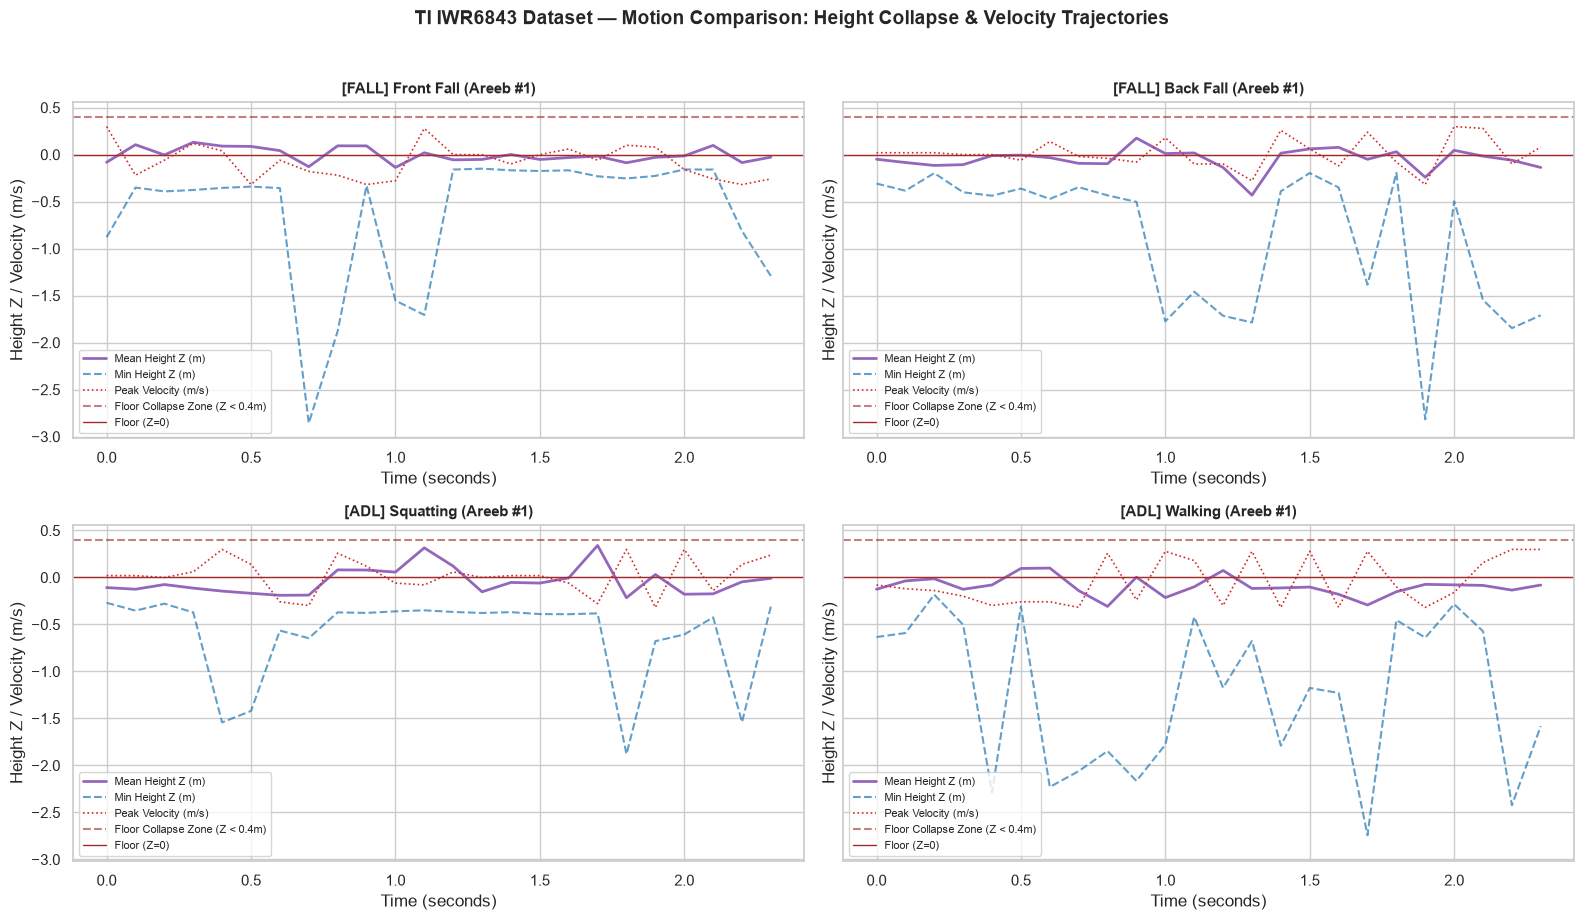

In [2]:
sample_trials = [
    ("Fall/Areeb_front_1.csv", "[FALL] Front Fall (Areeb #1)"),
    ("Fall/Areeb_back_1.csv", "[FALL] Back Fall (Areeb #1)"),
    ("Not/Areeb_squat_1.csv", "[ADL] Squatting (Areeb #1)"),
    ("Not/Areeb_walk_1.csv", "[ADL] Walking (Areeb #1)")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for idx, (rel_path, label) in enumerate(sample_trials):
    fpath = data_dir / rel_path
    if not fpath.exists():
        continue
        
    df_temp = pd.read_csv(fpath)
    df_temp["time_s"] = df_temp["frame"] / 10.0
    
    timeline = df_temp.groupby("frame").agg(
        mean_z=("z", "mean"),
        min_z=("z", "min"),
        peak_v=("v", lambda x: x.iloc[np.argmax(np.abs(x))]),
        time_s=("time_s", "first")
    ).reset_index()
    
    ax = axes[idx]
    ax.plot(timeline["time_s"], timeline["mean_z"], color="tab:purple", linewidth=2.0, label="Mean Height Z (m)")
    ax.plot(timeline["time_s"], timeline["min_z"], color="tab:blue", linestyle="--", alpha=0.7, label="Min Height Z (m)")
    ax.plot(timeline["time_s"], timeline["peak_v"], color="tab:red", linestyle=":", linewidth=1.2, label="Peak Velocity (m/s)")
    ax.axhline(0.4, color="darkred", linestyle="--", alpha=0.5, label="Floor Collapse Zone (Z < 0.4m)")
    ax.axhline(0.0, color="brown", linestyle="-", linewidth=1.0, label="Floor (Z=0)")
    
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Height Z / Velocity (m/s)")
    ax.legend(loc="lower left", fontsize=8)

plt.suptitle("TI IWR6843 Dataset — Motion Comparison: Height Collapse & Velocity Trajectories", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 3. Easy Interactive Motion Scrubber Dashboard

Use the interactive controls below:
1. **Recording Dropdown**: Pick any of the **102 CSV recordings** by Subject and Action name.
2. **Time Frame Slider**: Slide frame-by-frame across the recording ($0 \dots 25$ frames / $0.0\text{s} \dots 2.5\text{s}$).
3. **3 Synchronized Panels**: 3D Room Point Cloud View, Front Elevation View ($X$ vs $Z$), and Height Trajectory over time.


In [3]:
import ipywidgets as widgets

file_map = {}
for idx, row in df_radar_catalog.iterrows():
    lbl = f"{row['Class Label']} | Subject: {row['Subject']} | {row['Action Name']} ({row['File Name']})"
    file_map[lbl] = row["File Path"]

cache_radar = {}

def get_radar_df(filepath: str) -> pd.DataFrame:
    if filepath not in cache_radar:
        df = pd.read_csv(filepath)
        df["time_s"] = (df["frame"] / 10.0).round(2)
        cache_radar[filepath] = df
    return cache_radar[filepath]

drop_rec = widgets.Dropdown(
    options=list(file_map.keys()),
    value=list(file_map.keys())[0],
    description="Recording:",
    layout=widgets.Layout(width="75%")
)

df_init = get_radar_df(file_map[drop_rec.value])
max_f_init = int(df_init["frame"].max()) if len(df_init) > 0 else 25

slider_f = widgets.IntSlider(
    min=0, max=max_f_init, step=1, value=0,
    description="Time Frame:", continuous_update=False,
    layout=widgets.Layout(width="75%")
)

def on_rec_change(change):
    new_fp = file_map[change["new"]]
    df_new = get_radar_df(new_fp)
    new_max = int(df_new["frame"].max()) if len(df_new) > 0 else 25
    slider_f.max = new_max
    slider_f.value = 0

drop_rec.observe(on_rec_change, names="value")

def render_radar_view(rec_key: str, frame_idx: int):
    fp = file_map[rec_key]
    df = get_radar_df(fp)
    
    if len(df) == 0:
        return
        
    max_f = int(df["frame"].max())
    frame_idx = min(max(frame_idx, 0), max_f)
    t_s = frame_idx / 10.0
    
    timeline = df.groupby("frame").agg(
        mean_z=("z", "mean"),
        min_z=("z", "min"),
        peak_v=("v", lambda x: x.iloc[np.argmax(np.abs(x))]),
        time_s=("time_s", "first")
    ).reset_index()
    
    curr_mean_z = timeline[timeline["frame"] == frame_idx]["mean_z"].values[0] if len(timeline[timeline["frame"] == frame_idx]) else 1.5
    curr_min_z = timeline[timeline["frame"] == frame_idx]["min_z"].values[0] if len(timeline[timeline["frame"] == frame_idx]) else 1.5
    
    is_fall_file = "FALL" in rec_key
    is_collapsed = (curr_mean_z < 0.5) or (curr_min_z < 0.2)
    is_fall = is_fall_file and is_collapsed
    
    df_f = df[df["frame"] == frame_idx]
    
    fig = plt.figure(figsize=(16, 5))
    
   # 3D Point Cloud View
    ax1 = fig.add_subplot(1, 3, 1, projection="3d")
    if len(df_f) > 0:
        sc1 = ax1.scatter(df_f["x"], df_f["y"], df_f["z"], c=df_f["v"], cmap="coolwarm", vmin=-3.0, vmax=3.0, s=45, edgecolors="k", linewidths=0.3)
        fig.colorbar(sc1, ax=ax1, shrink=0.6, pad=0.08, label="Doppler v (m/s)")
    ax1.set_title(f"3D Point Cloud @ {t_s:.1f}s", fontweight="bold", fontsize=10)
    ax1.set_xlabel("X (Lateral, m)")
    ax1.set_ylabel("Y (Depth, m)")
    ax1.set_zlabel("Z (Height, m)")
    ax1.set_xlim(-2.0, 2.0)
    ax1.set_ylim(0.0, 6.0)
    ax1.set_zlim(-0.5, 2.2)
    
   # Front View (Elevation)
    ax2 = fig.add_subplot(1, 3, 2)
    if len(df_f) > 0:
        ax2.scatter(df_f["x"], df_f["z"], c=df_f["v"], cmap="coolwarm", vmin=-3.0, vmax=3.0, s=45)
    ax2.axhline(0.0, color="brown", linestyle="-", linewidth=1.2, label="Floor (Z=0)")
    ax2.set_title("Front Elevation View (X vs Z)", fontweight="bold", fontsize=10)
    ax2.set_xlabel("X (Lateral, m)")
    ax2.set_ylabel("Z (Height, m)")
    ax2.set_xlim(-2.0, 2.0)
    ax2.set_ylim(-0.5, 2.2)
    ax2.legend(loc="upper right", fontsize=8)
    
   # Height Timeline
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.plot(timeline["time_s"], timeline["mean_z"], color="tab:purple", linewidth=2.0, label="Mean Height Z (m)")
    ax3.plot(timeline["time_s"], timeline["min_z"], color="tab:blue", linestyle="--", alpha=0.7, label="Min Height Z (m)")
    ax3.plot(timeline["time_s"], timeline["peak_v"], color="tab:red", linestyle=":", linewidth=1.2, label="Peak Velocity (m/s)")
    ax3.axhline(0.4, color="darkred", linestyle=":", linewidth=1.2, label="Floor Zone (Z < 0.4m)")
    ax3.axvline(t_s, color="black", linestyle="--", linewidth=2.0, label=f"Current ({t_s:.1f}s)")
    ax3.set_title("Height Profile over Time", fontweight="bold", fontsize=10)
    ax3.set_xlabel("Time (seconds)")
    ax3.set_ylabel("Height Z / Velocity (m/s)")
    ax3.legend(loc="lower left", fontsize=8)
    
    if is_fall:
        status_str = f"[FALL DETECTED / ON FLOOR] - Mean Height Z = {curr_mean_z:.2f}m"
        status_col = "darkred"
    else:
        status_str = f"[NORMAL ADL MOTION] - Mean Height Z = {curr_mean_z:.2f}m"
        status_col = "darkgreen"
        
    plt.suptitle(f"{rec_key} | Frame {frame_idx}/{max_f} ({t_s:.1f}s)\nSTATUS: {status_str}", fontweight="bold", fontsize=12, color=status_col, y=1.05)
    plt.tight_layout()
    plt.show()

ui_radar = widgets.VBox([drop_rec, slider_f])
out_radar = widgets.interactive_output(render_radar_view, {"rec_key": drop_rec, "frame_idx": slider_f})
display(ui_radar, out_radar)


Output()